# Linear Regression and More

This code file includes my own notes and the course notes from my university lectures

1. Estimate Regression Equation
2. Prediction (F test & R squared test)
3. Inference (t test and relative strength of variables)
4. Models
    * Simple Regression (Continuous Predictor & Categorical Predictor)
    * Multiple Regression (With Interaction & Without Interaction & Polynomial Terms)
    * Generalized Additive Models
5. Regression Assumptions

## Estimate Regression Equation

**Theory:**
- Linear regression models the relationship between a dependent variable Y (outcome) and one or more independent variables X (predictors) using a linear equation. The general form of this relationship is:

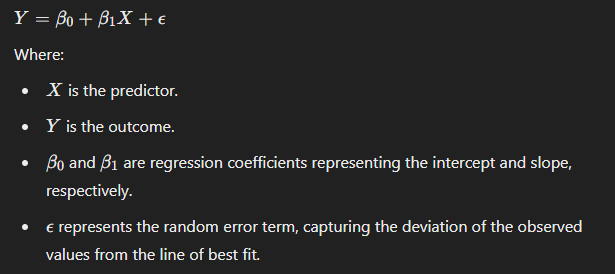

**Ordinary Least Squares (OLS):**
- OLS is a method used to estimate the parameters of a linear regression model. It minimizes the sum of the squared differences between the observed values and the values predicted by the linear model, known as the sum of squared errors (SSE).

Understanding Residuals (ei) and Sum of Resuduals

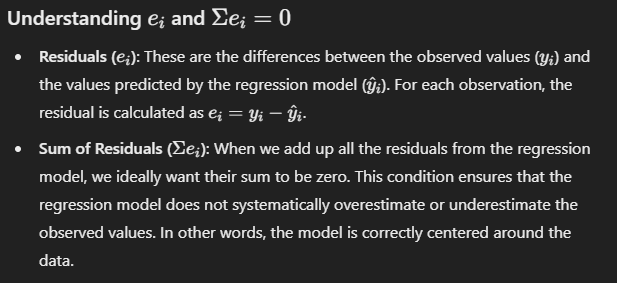

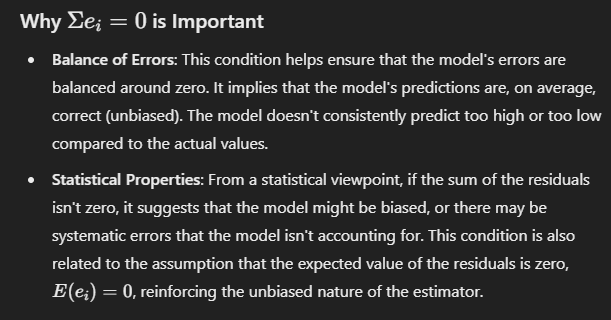

**Sum of Squared Errors (SSE) and Total Sum of Squares (SST)**
- **SSE:** The sum of the squared differences between each observed value and its corresponding predicted value.
- **SST:** The total sum of the squares of the differences between each observed value and the mean of the observed values. It measures the total variance in the observed data.

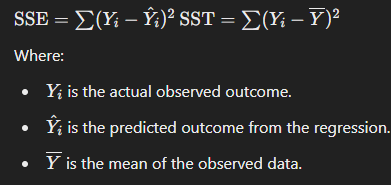

**Coefficient of Determination (R²)**
- R squared represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
- R squared values range from 0 to 1, where higher values indicate a better fit of the model to the data.

**Lecture Graph Example of Linear Model**

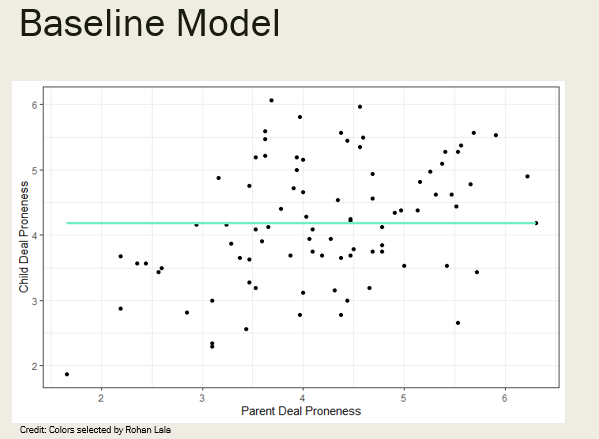

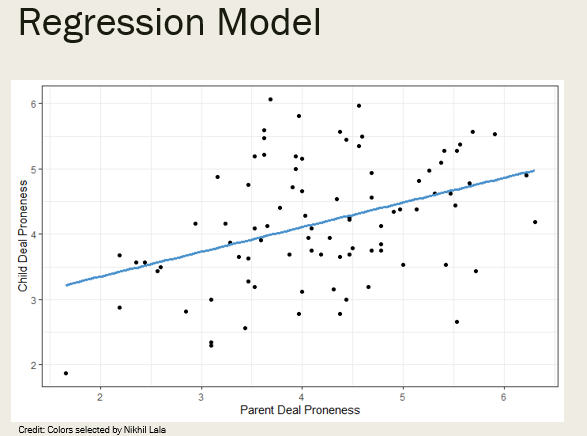

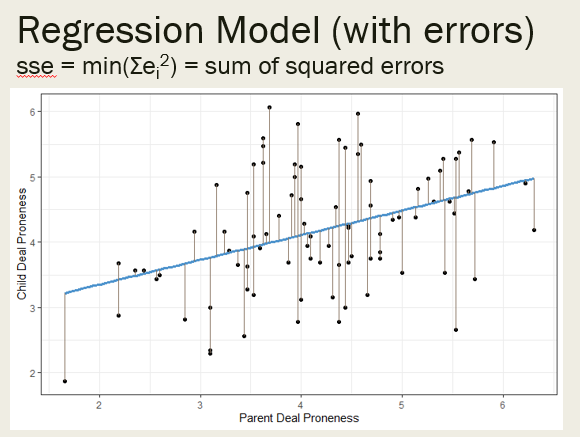

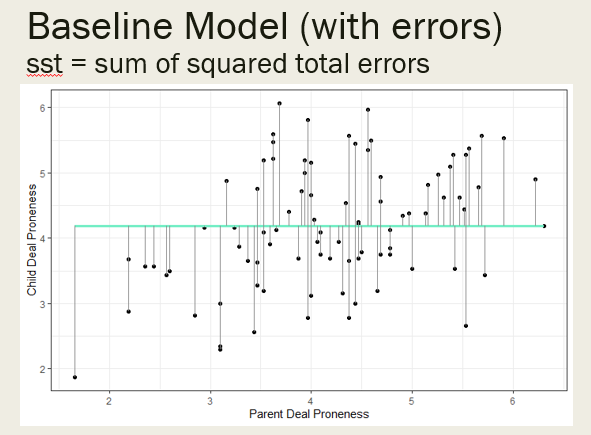

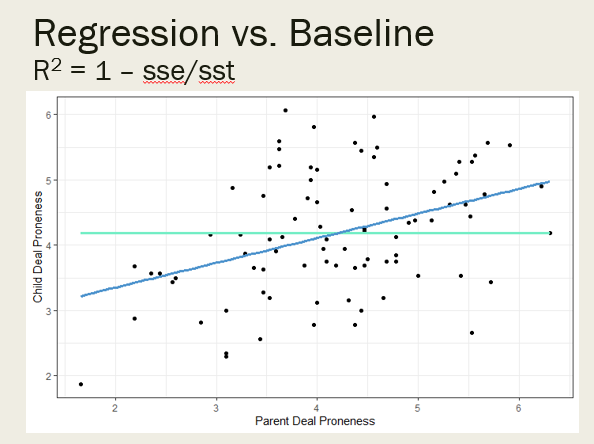

In [1]:
# Code Example of OLS regression, SSE, SST, and R squared
import numpy as np
import statsmodels.api as sm

# Generating synthetic data
np.random.seed(0)
X = np.random.rand(100, 1)  # Predictor
y = 2 + 3 * X.squeeze() + np.random.normal(0, 0.5, 100)  # Outcome

# Adding a constant for the intercept
X = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Print the summary
print(results.summary())

# Calculating SSE, SST
sse = np.sum((y - results.fittedvalues) ** 2)
sst = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (sse / sst)

print(f'SSE: {sse}')
print(f'SST: {sst}')
print(f'R^2: {r_squared}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     289.3
Date:                Sat, 21 Dec 2024   Prob (F-statistic):           5.29e-31
Time:                        23:45:36   Log-Likelihood:                -72.200
No. Observations:                 100   AIC:                             148.4
Df Residuals:                      98   BIC:                             153.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1111      0.097     21.843      0.0

In [2]:
# Example of Sum of Residuals
import numpy as np
import statsmodels.api as sm

# Generating some synthetic data
np.random.seed(0)
X = np.random.rand(100, 1)  # Independent variable
y = 2 + 3 * X.squeeze() + np.random.normal(0, 0.5, 100)  # Dependent variable with noise

# Adding a constant to include the intercept in the model
X = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Extracting residuals
residuals = results.resid

# Sum of residuals
sum_of_residuals = np.sum(residuals)
print("Sum of Residuals:", sum_of_residuals)

Sum of Residuals: -2.4158453015843406e-13


## Prediction

1. Statistical Test for Relationship

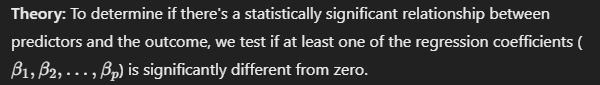

- **F-test:** This test compares a model with no predictors (only the intercept) against the proposed model with predictors. The F-statistic is calculated as follows:

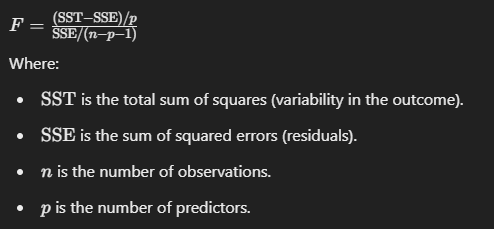

- **Statistical significance** of this test suggests that the predictors explain a significant amount of variability in the outcome compared to a model with no predictors.

2. Strength of the Relationship

**Coefficient of Determination R squared

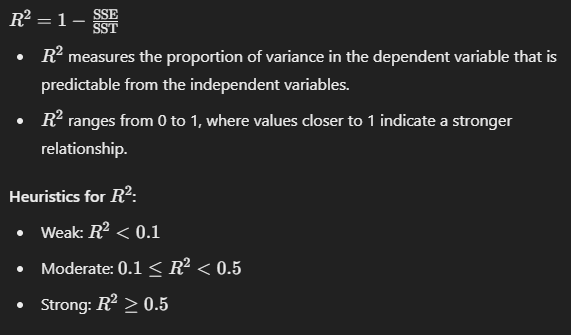

3. Accuracy of Predictions

- Residual-based metrics measure the accuracy of predictions:
    * Mean Squared Error (MSE)
    * Root Mean Squared Error (RMSE)
    * These metrics quantify the average magnitude of the prediction errors.

In [3]:
# Code Example of Prediction Section
import numpy as np
import statsmodels.api as sm

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 2)  # two predictors
y = 1 + 2 * X[:, 0] + 3 * X[:, 1] + np.random.normal(size=100)

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Display summary results which include F-statistic and R^2
print(results.summary())

# Calculate MSE and RMSE
mse = np.mean((y - results.fittedvalues)**2)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     51.18
Date:                Sun, 22 Dec 2024   Prob (F-statistic):           6.71e-16
Time:                        00:09:20   Log-Likelihood:                -133.53
No. Observations:                 100   AIC:                             273.1
Df Residuals:                      97   BIC:                             280.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1145      0.259      4.302      0.0

## Inference

1. Statistical Test for Individual Coefficients

**Theory:** 
- To understand the impact of individual predictors on the outcome, we use t-tests for each coefficient in the regression model. The t-statistic tests whether the coefficient is significantly different from zero.

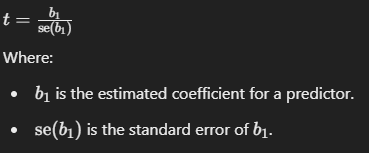

**Statistical Significance:** 
- If the absolute value of the t-statistic is large (typically greater than 2 in absolute value), it suggests that the predictor is statistically significant.

**What is the difference between the T-test and the F-test explained earlier?**

**F-test in Regression**
- Purpose: The F-test in regression is primarily used to test the overall significance of the regression model. It assesses whether at least one predictor variable has a non-zero coefficient.
- Calculation: The F-statistic is calculated using the ratio of two variances:
    * Model Variance: This is the variance explained by the model and is computed as the ratio of the regression sum of squares (RSS) to the number of restrictions (degrees of freedom of the regression).
    * Residual Variance: This is the unexplained variance, computed as the ratio of the residual sum of squares (RSS) to the residual degrees of freedom (number of observations minus the number of estimated parameters).

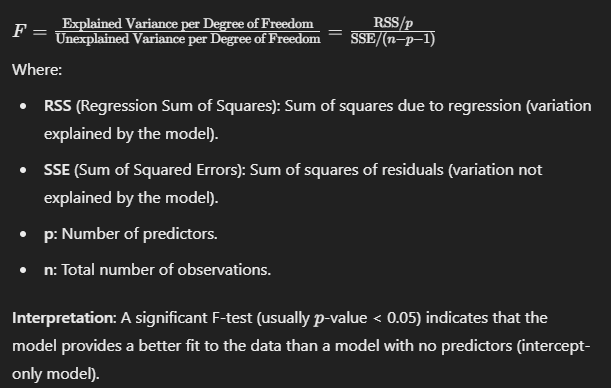

**T-test for Individual Coefficients**
- Purpose: The t-test in regression is used to assess the statistical significance of individual coefficients. It tests whether each coefficient is significantly different from zero, indicating that the corresponding predictor has an influence on the response variable.
- Calculation: The t-statistic for a coefficient is calculated as the ratio of the coefficient to its standard error:

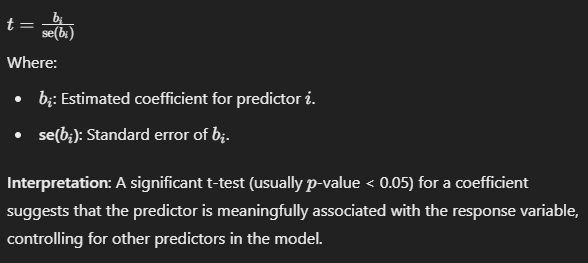

**Differences and Relationships**
* Scope: The F-test evaluates the joint effect of all predictors included in the model, while the t-test evaluates the individual effect of each predictor.
* Use Cases: The F-test is useful for testing the overall model fit or comparing nested models, whereas t-tests are useful for assessing the impact of specific predictors.
* Dependency: All coefficients could have non-significant t-tests, but the F-test could still be significant if the predictors collectively explain variation in the response variable, especially in cases where predictors are correlated.

2. Interpretation of Coefficients
- Theory: The coefficient tells us how much the dependent variable Y is expected to increase (or decrease) with a one-unit increase in X, holding all other predictors constant.

3. Nature of the Relationship

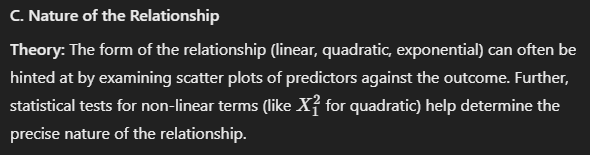

4. Relative Strength of Varialbes

**Theory:** 
- Standardized coefficients, often called beta coefficients, help compare the relative strength of predictors within the same model. They are scaled versions of the coefficients and indicate ***how many standard deviations a dependent variable will change, per standard deviation increase in the predictor***.

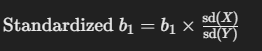


In [4]:
# Code example for Inference Part
import numpy as np
import statsmodels.api as sm

# Generate synthetic data
np.random.seed(1)
X = np.random.normal(0, 1, 100)
Y = 2 + 3 * X + np.random.normal(0, 2, 100)  # Linear relationship

# Add a constant to the predictor
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(Y, X)
results = model.fit()

# Output the summary of the model
print(results.summary())

# Calculating standardized coefficients
std_b1 = results.params[1] * (np.std(X[:,1]) / np.std(Y))
print(f"Standardized coefficient for X1: {std_b1}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     226.9
Date:                Sun, 22 Dec 2024   Prob (F-statistic):           3.00e-27
Time:                        00:34:23   Log-Likelihood:                -203.75
No. Observations:                 100   AIC:                             411.5
Df Residuals:                      98   BIC:                             416.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2940      0.188     12.205      0.0

## Regression Models

* Simple Regression
    - Continuous Predictor
    - Categorical Predictor
* Multiple Regression 
    - With Interaction 
    - Without Interaction 
    - Polynomial Terms
* Generalized Additive Models

### Simple Regression - Continuous Predictor
- **Theory:** Simple linear regression involves a single continuous predictor variable. It models the relationship between the predictor X and the response Y as linear.
- Parametric: Yes, because it assumes a specific form for the relationship.

**Linear Regression**
- Underlying Theory: Linear regression models the relationship between a scalar dependent variable y and one or more independent variables (or predictors) X. The model is linear in the parameters, meaning it can be written as:

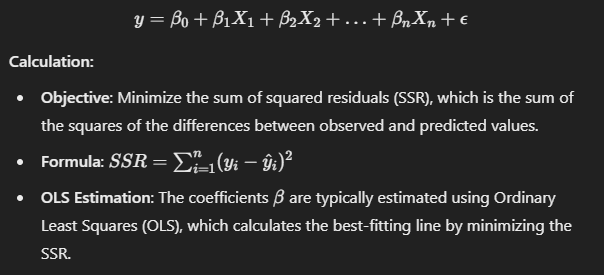

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     340.1
Date:                Sun, 22 Dec 2024   Prob (F-statistic):           1.24e-33
Time:                        00:53:06   Log-Likelihood:                -141.51
No. Observations:                 100   AIC:                             287.0
Df Residuals:                      98   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7222      0.193     14.083      0.0

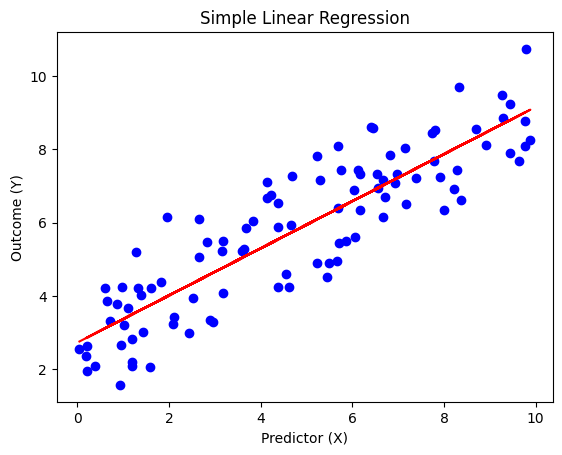

In [5]:
# Code Example for Simple Regression
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 1) * 10  # Continuous predictor
y = 2.5 + 0.65 * X.squeeze() + np.random.normal(size=100)  # Linear relationship

# Fit a simple linear regression model
X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

# Plotting the results
plt.scatter(X[:, 1], y, color='blue')
plt.plot(X[:, 1], results.fittedvalues, color='red')
plt.title('Simple Linear Regression')
plt.xlabel('Predictor (X)')
plt.ylabel('Outcome (Y)')
plt.show()

### Simple Regression - Categorical Predictor
- **Theory:** Uses dummy variables to encode categories. Each coefficient of a dummy variable represents the mean difference from the reference category.
- Parametric: Yes, as it still relies on the linear model framework.

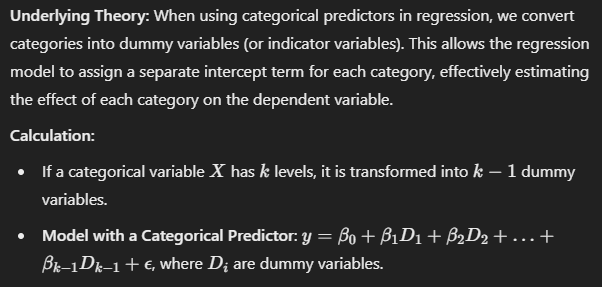

In [9]:
# Code example for categorical predictor
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Create sample data
data = pd.DataFrame({
    'Y': [10, 12, 10, 15, 20, 15],
    'X': ["Red", "Blue", "Green", "Red", "Blue", "Green"]
})

# Convert categorical variable into dummy variables
X = pd.get_dummies(data['X'], drop_first=True)  # Drop the first category to avoid multicollinearity

# Convert all columns to float explicitly and check for any null values
X = X.astype(float)
if X.isnull().any().any():
    print("Null values found in X")
    
# Add a constant term to X manually to ensure float type
X['const'] = 1.0

# Ensure that data['Y'] is of a compatible type
data['Y'] = data['Y'].astype(float)

# Print data types for debugging
print("Data Types in X:\n", X.dtypes)
print("Data Type of Y:", data['Y'].dtype)

# Fit the model
model = sm.OLS(data['Y'], X)
results = model.fit()
print(results.summary())


Data Types in X:
 Green    float64
Red      float64
const    float64
dtype: object
Data Type of Y: float64
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                 -0.295
Method:                 Least Squares   F-statistic:                    0.4298
Date:                Sun, 22 Dec 2024   Prob (F-statistic):              0.685
Time:                        01:02:53   Log-Likelihood:                -15.268
No. Observations:                   6   AIC:                             36.54
Df Residuals:                       3   BIC:                             35.91
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------

c:\Users\Michael\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### Multiple Regression - With & Without Interaction


**Underlying Theory:** Multiple regression models the relationship between a dependent variable and multiple independent variables. It can incorporate both continuous and categorical predictors and can evaluate the interactions between variables.

**Calculations**

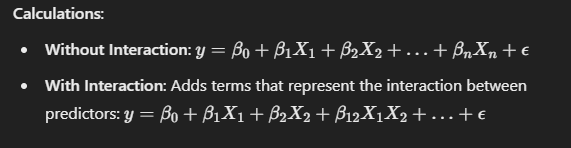

**Benefits and Drawbacks:**
- Without Interaction:
    * Benefits: Simpler model, easier to interpret.
    * Drawbacks: May miss out on important relationships between variables.
- With Interaction:
    * Benefits: Can capture complex interdependencies between variables.
    * Drawbacks: More complex model, risk of overfitting, harder to interpret.

In [1]:
# Code Example for without Interaction
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Create synthetic data
np.random.seed(0)
data = pd.DataFrame({
    'X1': np.random.normal(0, 1, 100),
    'X2': np.random.normal(0, 1, 100),
    'Y': np.random.normal(0, 1, 100) + 1.5 * np.random.normal(0, 1, 100)
})

# Add a constant to the model (intercept)
X = sm.add_constant(data[['X1', 'X2']])

# Fit the model
model = sm.OLS(data['Y'], X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.4106
Date:                Sun, 29 Dec 2024   Prob (F-statistic):              0.664
Time:                        21:37:43   Log-Likelihood:                -199.40
No. Observations:                 100   AIC:                             404.8
Df Residuals:                      97   BIC:                             412.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3657      0.181     -2.018      0.0

In [2]:
# Code Example for with interaction
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Set random seed for reproducibility
np.random.seed(0)

# Create synthetic data for predictors X1 and X2
data = pd.DataFrame({
    'X1': np.random.normal(0, 1, 100),
    'X2': np.random.normal(0, 1, 100)
})

# Creating a response variable 'Y' based on X1, X2 and their interaction plus some noise
data['Y'] = 2 + 1.5 * data['X1'] - 2 * data['X2'] + 1.2 * data['X1'] * data['X2'] + np.random.normal(0, 1, 100)

# Generate interaction term between X1 and X2
data['X1_X2'] = data['X1'] * data['X2']

# Add a constant term for the intercept to the model
X = sm.add_constant(data[['X1', 'X2', 'X1_X2']])

# Fit the multiple regression model including the interaction term
model = sm.OLS(data['Y'], X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     266.6
Date:                Sun, 29 Dec 2024   Prob (F-statistic):           2.07e-46
Time:                        21:37:46   Log-Likelihood:                -134.90
No. Observations:                 100   AIC:                             277.8
Df Residuals:                      96   BIC:                             288.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9123      0.096     19.862      0.0

### Multiple Regression - Polynomial Terms

**Underlying Theory**: Polynomial regression is a form of regression analysis in which the relationship between the independent variable(s) and the dependent variable is modeled as an nth degree polynomial. Polynomial regression fits a nonlinear relationship into a linear model, which means that the regression function is linear in terms of the coefficients, even though it may be nonlinear in terms of the actual variables.

**Calculation**

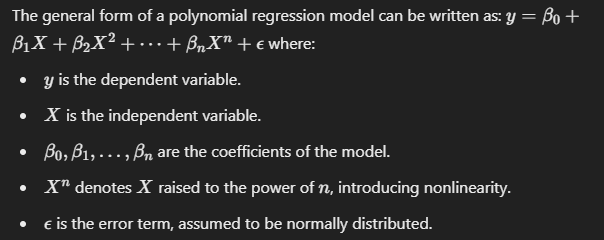

**Benefits**
- Flexibility: Polynomial regression can model a wide range of curvature in the data by adjusting the degree of the polynomial.
- Simple to Implement: Despite its ability to fit complex models, it remains a linear model in terms of estimation and is handled easily by most statistical software.
- Good Approximation: It can provide an excellent approximation to the relationship between variables even if the actual relationship is unknown.

**Drawbacks**
- Overfitting: Higher-degree polynomials can lead to overfitting, especially with insufficient data or when the degree is too high.
- Extrapolation Danger: Polynomial models can produce wildly varying predictions at the extremes of the input variable range.
- Model Complexity: The interpretation of the model becomes more challenging as the degree of the polynomial increases. Coefficients of higher powers of X can be difficult to interpret in a business or scientific context.

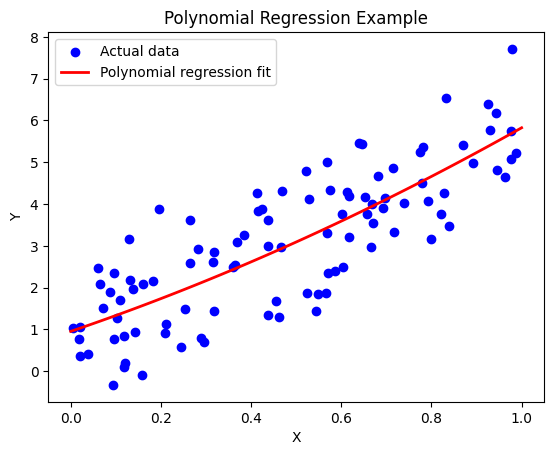

In [4]:
# Code Example for Polynomial Regression Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 1)  # One predictor
y = 1 + 2*X.squeeze() + 3*X.squeeze()**2 + np.random.normal(size=100)  # Quadratic relationship

# Generate polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit the polynomial regression model
model = LinearRegression().fit(X_poly, y)

# Prepare X values for plotting the fitted curve
X_fit = np.linspace(0, 1, 100).reshape(-1, 1)
X_fit_poly = poly.transform(X_fit)  # Transform these values for polynomial regression

# Predict y values for plotting
y_fit = model.predict(X_fit_poly)

# Plotting the results
plt.scatter(X, y, color='blue', label='Actual data')
plt.plot(X_fit, y_fit, color='red', label='Polynomial regression fit', linewidth=2)  # Ensure the line is visible
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Polynomial Regression Example')
plt.legend()
plt.show()

### Generalized Additive Models
**Underlying Theory:** Generalized Additive Models (GAMs) extend linear models by allowing non-linear functions of each of the variables while maintaining the overall additivity of the model. This approach allows for more flexibility than traditional linear regression because it can model complex behaviors in data without assuming a specific form for the entire model. Each predictor has its own smooth function that is automatically fitted to the data, providing a clear visualization of the relationship between the independent and dependent variables.

**Calculation**

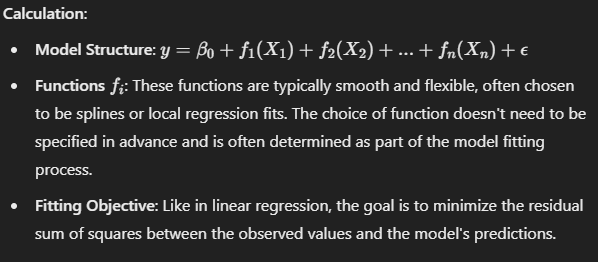

**Benefits:**
- Flexibility: GAMs can capture complex nonlinear relationships without assuming a specific functional form for the entire dataset.
- Interpretability: Each variable's effect is modeled separately as an additive function, making the results easier to interpret than some other non-linear models.
- Adaptability: GAMs can automatically adapt to the structure of the data by choosing appropriate smoothness levels for the functions.

**Drawbacks:**
- Complexity: While more flexible, GAMs are computationally more complex and may require more data to fit effectively.
- Overfitting Risk: Without proper control of the smoothness, these models can overfit, particularly with a small sample size or very flexible function choices.
- Model Selection and Checking: Selecting the correct form for fi and the amount of smoothing can be non-trivial and requires careful validation

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     18.5039
Link Function:                     IdentityLink Log Likelihood:                                 -3979.4814
Number of Samples:                          100 AIC:                                             7997.9706
                                                AICc:                                            8008.0316
                                                GCV:                                                0.0139
                                                Scale:                                              0.0094
                                                Pseudo R-Squared:                                   0.9935
Feature Function                  Lam

C:\Users\Michael\AppData\Local\Temp\ipykernel_3764\2749461079.py:15: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


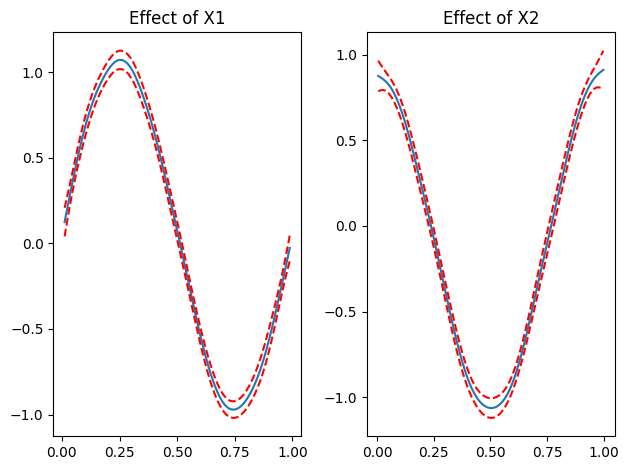

In [3]:
# Code example for GAM using spline
import numpy as np
from pygam import LinearGAM, s
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 2)  # Two predictors
y = 1 + np.sin(2 * np.pi * X[:, 0]) + np.cos(2 * np.pi * X[:, 1]) + np.random.normal(scale=0.1, size=100)

# Fit GAM with spline terms for each predictor
gam = LinearGAM(s(0) + s(1)).fit(X, y)

# Summary of the model
print(gam.summary())

# Plot the partial dependence for each feature
fig, axs = plt.subplots(1, 2)
titles = ['Effect of X1', 'Effect of X2']
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(titles[i])
plt.tight_layout()
plt.show()

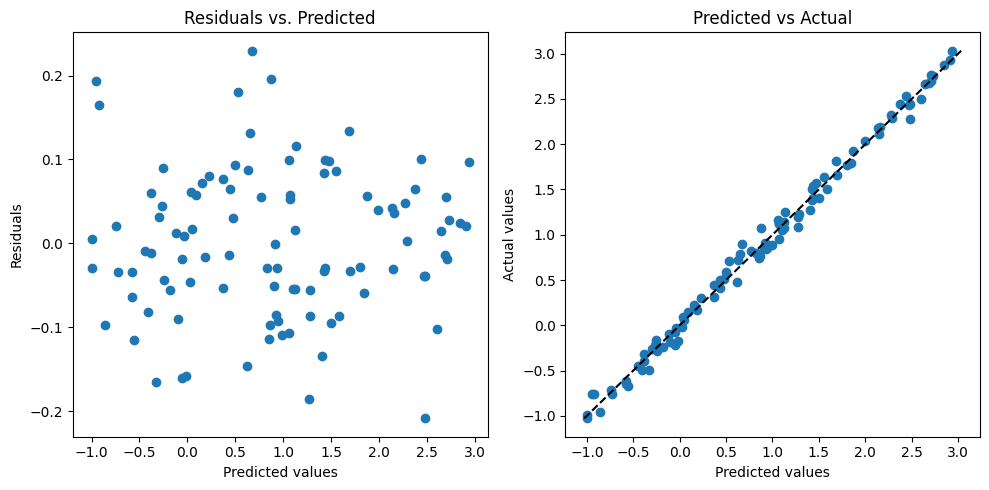

In [4]:
import matplotlib.pyplot as plt

# Predict using the GAM model
y_pred = gam.predict(X)

# Plot residuals
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, y - y_pred)
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

# Plot predicted vs actual
plt.subplot(1, 2, 2)
plt.scatter(y_pred, y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.title('Predicted vs Actual')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')

plt.tight_layout()
plt.show()

## Regression Assumptions

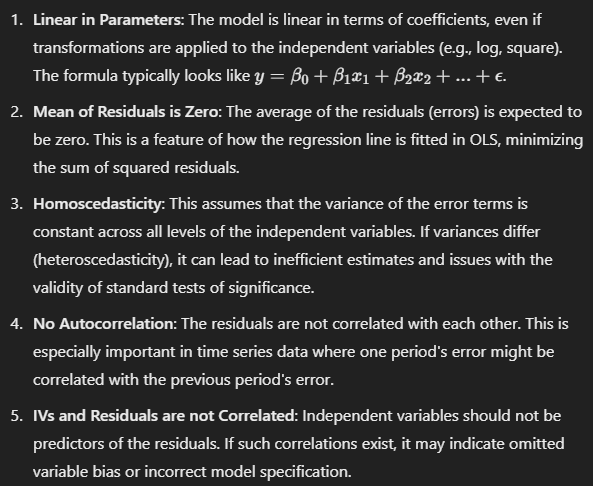

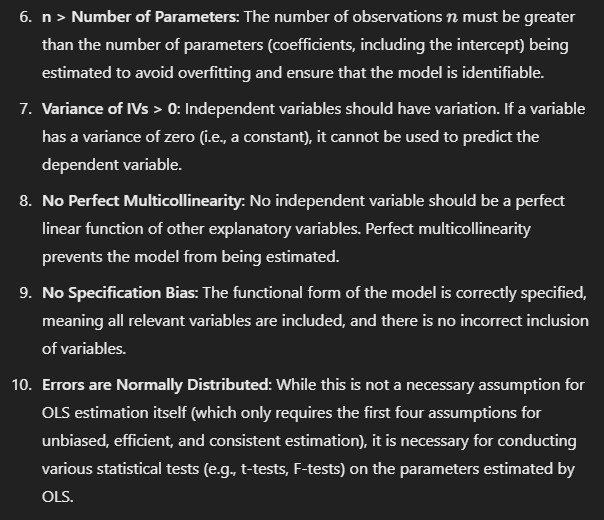

**Summary**
Regression models are based on several key assumptions which, if violated, can impact the model's effectiveness and the interpretability of the results. Validating these assumptions using various diagnostic tools and tests (like residual plots, variance inflation factor for multicollinearity, Durbin-Watson test for autocorrelation) is crucial before finalizing a model for inference or prediction. Addressing violations through transformations, adding variables, or using different estimation techniques helps in achieving more reliable and robust model outputs.